# **Proyek Analisis Data: Bike Sharing Dataset**
- **Nama:** Novia Djoend Lestari
- **Email:** CDCC284D6X2740@student.devacademy.id
- **ID Dicoding:** CDCC284D6X2740

# **Menentukan Pertanyaan Bisnis**

- Bagaimana tren jumlah penyewaan sepeda per bulan selama periode 2011-2012, dan pada bulan apa terjadi kenaikan atau penurunan terbesar berdasarkan perubahan jumlah penyewaan?
- Bagaimana hubungan antara suhu, kelembaban, dan kondisi cuaca terhadap jumlah penyewaan sepeda selama periode 2011-2012?
- Pada jam berapa terjadi puncak penyewaan sepeda dalam satu hari, dan bagaimana perbedaannya antara hari kerja dan hari libur?

# **Informasi Dataset**

Dataset ini menyajikan gambaran mengenai pola penyewaan sepeda dan aktivitas pengguna berdasarkan waktu serta kondisi lingkungan. Dataset ini sangat cocok digunakan untuk analisis perilaku pengguna, identifikasi pola musiman, serta memahami faktor-faktor yang memengaruhi jumlah penyewaan sepeda.

Dataset mencakup data historis selama periode tahun 2011-2012 di Washington D.C., Amerika Serikat, yang terdiri dari data harian dan data per jam. Data ini juga telah diperkaya dengan informasi cuaca seperti suhu, kelembaban, dan kecepatan angin.

Setiap entri dalam dataset memberikan informasi yang dapat digunakan untuk analisis tren, pengaruh cuaca, serta pola penggunaan sepeda berdasarkan waktu.

#

# **Fitur Utama**

- `instant` : Indeks unik untuk setiap data
- `dteday` : Tanggal penyewaan
- `season` : Musim (1: Spring, 2: Summer, 3: Fall, 4: Winter)
- `yr` : Tahun (0: 2011, 1: 2012)
- `mnth` : Bulan (1–12)
- `hr` : Jam (0–23, hanya pada hour.csv)
- `holiday` : Menunjukkan apakah hari tersebut merupakan hari libur
- `weekday` : Hari dalam seminggu
- `workingday` : Hari kerja atau bukan
- `weathersit` : Kondisi cuaca (Clear, Mist, Rain, Snow)
- `temp` : Suhu (sudah dinormalisasi)
- `atemp` : Suhu yang dirasakan
- `hum` : Kelembaban
- `windspeed` : Kecepatan angin
- `casual` : Jumlah pengguna kasual
- `registered` : Jumlah pengguna terdaftar
- `cnt` : Total penyewaan sepeda

# **Import Library**


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# **Data Wrangling**

## Gathering Data

In [23]:
day_df = pd.read_csv('day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [24]:
hour_df = pd.read_csv('hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## Assessing Data

#### Daily Dataset

In [25]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [26]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [27]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [28]:
day_df.duplicated().sum()

np.int64(0)

**Insight:**

Berdasarkan hasil pemeriksaan data:
- Dataset memiliki jumlah data yang lengkap dengan tipe data yang sudah sesuai, terutama kolom tanggal yang dapat dikonversi ke format datetime.
- Tidak ditemukan missing value pada seluruh kolom, sehingga data dapat langsung digunakan tanpa perlu penanganan nilai kosong.
- Berdasarkan statistik deskriptif:
  Rata-rata jumlah penyewaan (cnt) berada pada kisaran ±4.500. Nilai minimum sekitar 22, sedangkan maksimum mencapai ±8.700, menunjukkan adanya variasi yang cukup besar dalam jumlah penyewaan harian.
- Tidak terdapat data duplikat, sehingga kualitas data cukup baik dan tidak perlu proses penghapusan duplikasi.

#### Hourly Dataset

In [29]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [30]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [31]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [32]:
hour_df.duplicated().sum()

np.int64(0)

**Insight:**

Berdasarkan hasil pemeriksaan data:
- Dataset memiliki jumlah data yang lebih besar karena berbasis per jam, sehingga memungkinkan analisis yang lebih detail.
- Tidak ditemukan missing value pada dataset, sehingga data bersih dan siap digunakan.
- Berdasarkan statistik deskriptif:
  Rata-rata penyewaan per jam lebih kecil (±189) dibanding harian karena granularitas data. Nilai minimum 1 dan maksimum mendekati 1000, menunjukkan adanya variasi signifikan pada jam-jam tertentu.
- Tidak terdapat data duplikat, sehingga tidak ada redundansi data.

## Cleaning Data

In [33]:
# Ubah tipe data tanggal
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

# Mapping kategori
day_df['yr'] = day_df['yr'].map({0: 2011, 1: 2012})

day_df['season'] = day_df['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

day_df['weathersit'] = day_df['weathersit'].map({
    1: 'Clear',
    2: 'Mist',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Snow'
})

# Rename kolom
day_df.rename(columns={
    'dteday': 'date',
    'yr': 'year',
    'mnth': 'month',
    'cnt': 'total_rentals'
}, inplace=True)

# Drop kolom tidak penting
day_df.drop(columns=['instant'], inplace=True)

# Tambah fitur baru
day_df['day_category'] = day_df['workingday'].map({
    0: 'Weekend/Holiday',
    1: 'Working Day'
})

day_df.head()

,date,season,year,month,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,total_rentals,day_category
0,2011-01-01,Spring,2011,1,0,6,0,Mist,0.344167,0.363625,0.805833,0.160446,331,654,985,Weekend/Holiday
1,2011-01-02,Spring,2011,1,0,0,0,Mist,0.363478,0.353739,0.696087,0.248539,131,670,801,Weekend/Holiday
2,2011-01-03,Spring,2011,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349,Working Day
3,2011-01-04,Spring,2011,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562,Working Day
4,2011-01-05,Spring,2011,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600,Working Day


**Insight:**

Berdasarkan proses cleaning:
- Perubahan tipe data tanggal
  - Kolom dteday diubah menjadi format datetime (date)
  → Mempermudah analisis berbasis waktu (tren bulanan/tahunan)
- Mapping kategori (yr, season, weathersit)
  - Data numerik diubah menjadi kategori yang lebih deskriptif:
    - yr → 2011, 2012
    - season → Spring, Summer, Fall, Winter
    - weathersit → Clear, Mist, Light Snow/Rain, Heavy Rain/Snow
    → Membuat data lebih mudah dipahami dan divisualisasikan
- Rename kolom
  - Nama kolom dibuat lebih jelas seperti date, year, month, total_rentals
  → Meningkatkan keterbacaan dataset
- Menghapus kolom tidak penting (instant)
  → Mengurangi noise dan fokus pada fitur yang relevan
- Feature Engineering (day_category)
  - Menambahkan kategori hari:
    - Working Day
    - Weekend/Holiday
    → Memungkinkan analisis perbedaan pola perilaku pengguna

Proses data cleaning berhasil mengubah dataset menjadi lebih terstruktur, mudah dipahami, dan siap untuk analisis lanjutan. Penambahan fitur seperti kategori hari juga memberikan nilai tambah dalam mengeksplorasi perbedaan pola penyewaan berdasarkan jenis hari.

In [34]:
# Ubah tipe data tanggal
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Mapping kategori
hour_df['yr'] = hour_df['yr'].map({0: 2011, 1: 2012})

hour_df['season'] = hour_df['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

hour_df['weathersit'] = hour_df['weathersit'].map({
    1: 'Clear',
    2: 'Mist',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Snow'
})

# Rename kolom
hour_df.rename(columns={
    'dteday': 'date',
    'yr': 'year',
    'mnth': 'month',
    'hr': 'hour',
    'cnt': 'total_rentals'
}, inplace=True)

# Drop kolom tidak penting
hour_df.drop(columns=['instant'], inplace=True)

# Tambah fitur kategori hari
hour_df['day_category'] = hour_df['workingday'].map({
    0: 'Weekend/Holiday',
    1: 'Working Day'
})

hour_df.head()

,date,season,year,month,hour,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,total_rentals,day_category
0,2011-01-01,Spring,2011,1,0,0,6,0,Clear,0.24,0.2879,0.81,0.0,3,13,16,Weekend/Holiday
1,2011-01-01,Spring,2011,1,1,0,6,0,Clear,0.22,0.2727,0.80,0.0,8,32,40,Weekend/Holiday
2,2011-01-01,Spring,2011,1,2,0,6,0,Clear,0.22,0.2727,0.80,0.0,5,27,32,Weekend/Holiday
3,2011-01-01,Spring,2011,1,3,0,6,0,Clear,0.24,0.2879,0.75,0.0,3,10,13,Weekend/Holiday
4,2011-01-01,Spring,2011,1,4,0,6,0,Clear,0.24,0.2879,0.75,0.0,0,1,1,Weekend/Holiday


**Insight:**

Berdasarkan proses cleaning:
- Perubahan tipe data tanggal
  → Mendukung analisis berbasis waktu hingga level jam
- Mapping kategori
  → Konsistensi dengan dataset harian (day_df) sehingga memudahkan analisis gabungan
- Penambahan kolom hour
  → Memungkinkan analisis pola penyewaan berdasarkan waktu dalam sehari
- Rename kolom
  → Memperjelas arti setiap variabel
- Menghapus kolom tidak penting (instant)
  → Mengurangi kompleksitas data
- Feature Engineering (day_category)
  → Memungkinkan analisis perbedaan antara hari kerja dan akhir pekan pada level jam

Data cleaning pada dataset hourly memungkinkan analisis yang lebih detail terhadap pola penyewaan sepeda dalam satu hari. Dengan adanya fitur jam dan kategori hari, analisis dapat menggambarkan perilaku pengguna secara lebih spesifik, seperti pola komuter dan aktivitas rekreasi.

# **Exploratory Data Analysis (EDA)**

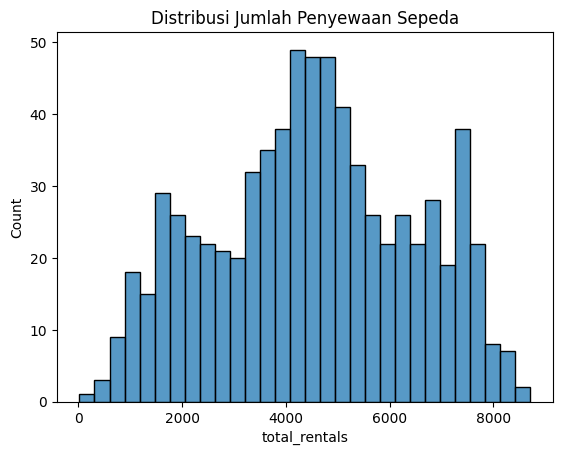

In [35]:
sns.histplot(day_df['total_rentals'], bins=30)
plt.title('Distribusi Jumlah Penyewaan Sepeda')
plt.show()

**Insight:**
- Distribusi cenderung mendekati normal (bell-shaped)
- Mayoritas penyewaan berada di kisaran 4000-6000 sepeda per hari
- Terdapat beberapa nilai ekstrem:
  - Sangat rendah (<1000) → kemungkinan kondisi cuaca buruk / hari tertentu
  - Sangat tinggi (>8000) → kemungkinan peak season / kondisi ideal

Permintaan sepeda relatif stabil, namun tetap dipengaruhi oleh faktor tertentu yang menyebabkan lonjakan atau penurunan ekstrem.

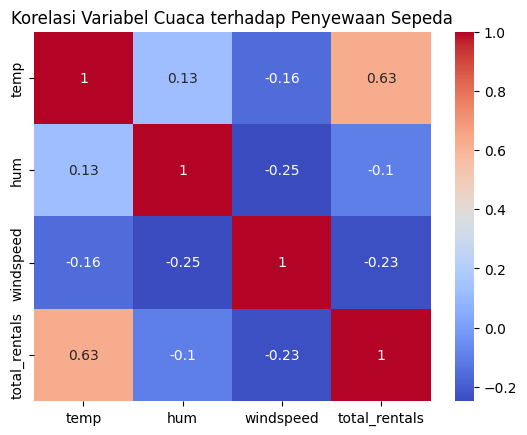

In [36]:
corr = day_df[['temp','hum','windspeed','total_rentals']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Korelasi Variabel Cuaca terhadap Penyewaan Sepeda')
plt.show()

**Insight:**
- Suhu (temp) → korelasi +0.63 (cukup kuat)
  Semakin tinggi suhu → penyewaan meningkat
- Kelembaban (hum) → korelasi -0.10 (lemah negatif)
  Tidak terlalu berpengaruh signifikan
- Kecepatan angin (windspeed) → korelasi -0.23 (negatif)
  Angin kencang → penyewaan menurun

Faktor paling berpengaruh adalah suhu, sedangkan kelembaban dan angin memiliki pengaruh negatif namun tidak terlalu kuat.

<Axes: xlabel='season', ylabel='total_rentals'>

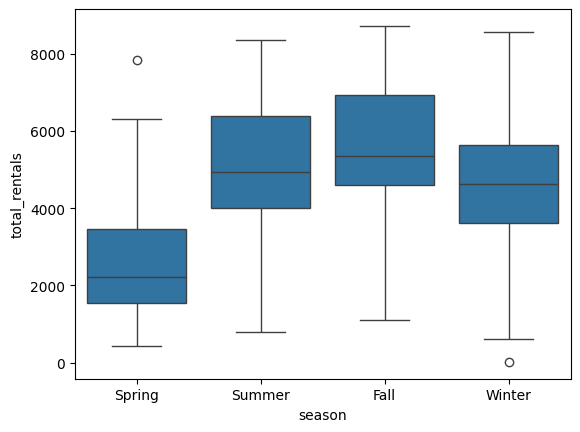

In [37]:
sns.boxplot(x=day_df['season'], y=day_df['total_rentals'])

**Insight:**
- Fall (Musim Gugur) → median tertinggi (paling banyak penyewaan)
- Summer → juga tinggi
- Winter → menurun
- Spring → paling rendah
- Variasi:
  - Fall & Summer → lebih stabil dan tinggi
  - Spring → rendah dan lebih bervariasi

Penyewaan sepeda cenderung tinggi pada musim dengan kondisi cuaca nyaman (Fall & Summer), dan menurun pada musim dingin atau awal tahun.

# **Visualization & Explanatory Analysis**

## Pertanyaan 1:

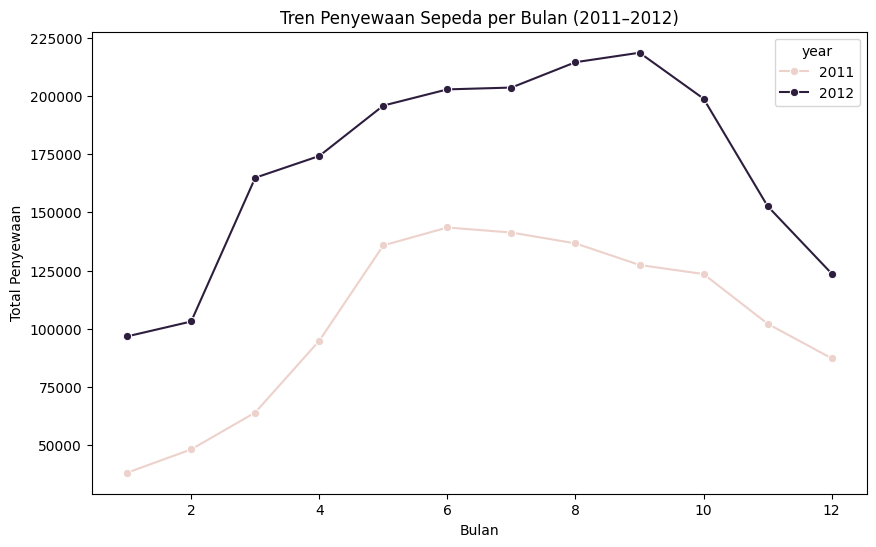

In [38]:
monthly = day_df.groupby(['year','month'])['total_rentals'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=monthly, x='month', y='total_rentals', hue='year', marker='o')

plt.title('Tren Penyewaan Sepeda per Bulan (2011–2012)')
plt.xlabel('Bulan')
plt.ylabel('Total Penyewaan')
plt.show()

**Insight:**
- Berdasarkan visualisasi:
  - Pada tahun 2011, jumlah penyewaan meningkat dari sekitar ±40.000 pada   Januari hingga mencapai puncak sekitar ±145.000 pada bulan Juni, kemudian cenderung menurun hingga ±90.000 pada Desember.
  - Pada tahun 2012, pola yang sama juga terlihat, namun dengan jumlah yang lebih tinggi. Penyewaan meningkat dari sekitar ±100.000 pada Januari hingga mencapai puncak sekitar ±220.000 pada bulan September, lalu menurun hingga ±125.000 pada Desember.
- Kenaikan signifikan
  - Terjadi pada awal hingga pertengahan tahun (Januari-Juni)
  - Contoh: tahun 2012 meningkat dari ±100.000 → ±200.000
- Penurunan signifikan
  - Terjadi pada akhir tahun (Oktober-Desember)
  - Contoh: tahun 2012 turun dari ±200.000 → ±125.000
- Tahun 2012 secara konsisten lebih tinggi dibandingkan 2011
- Selisih rata-rata mencapai sekitar 50.000-80.000 penyewaan per bulan

Tren penyewaan sepeda menunjukkan pola musiman yang jelas, di mana jumlah penyewaan meningkat dari awal tahun dan mencapai puncaknya pada pertengahan hingga akhir tahun, khususnya pada bulan September 2012 dengan sekitar 220.000 penyewaan. Setelah itu, terjadi penurunan signifikan menjelang akhir tahun. Selain itu, jumlah penyewaan pada tahun 2012 secara konsisten lebih tinggi dibandingkan tahun 2011, yang mengindikasikan adanya peningkatan penggunaan layanan bike sharing dari waktu ke waktu.

## Pertanyaan 2:

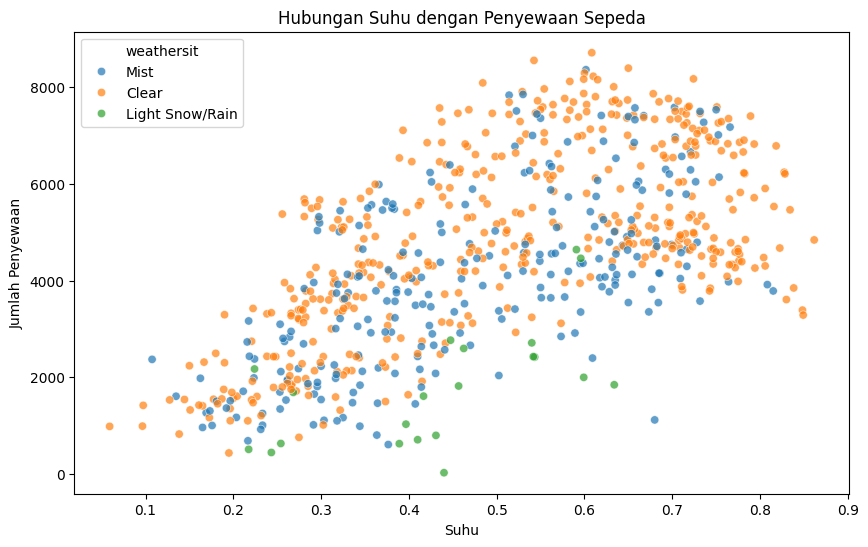

In [39]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=day_df, x='temp', y='total_rentals', hue='weathersit', alpha=0.7)

plt.title('Hubungan Suhu dengan Penyewaan Sepeda')
plt.xlabel('Suhu')
plt.ylabel('Jumlah Penyewaan')
plt.show()

**Insight:**
- Semakin tinggi suhu (temp), jumlah penyewaan cenderung meningkat, dengan nilai penyewaan mencapai ±8000-9000 pada suhu tinggi (sekitar 0.6-0.8).
- Pada kondisi cuaca Clear, jumlah penyewaan lebih tinggi dibandingkan kondisi Mist maupun Light Snow/Rain.
- Pada kondisi Light Snow/Rain, penyewaan cenderung rendah, sebagian besar berada di bawah ±4000.

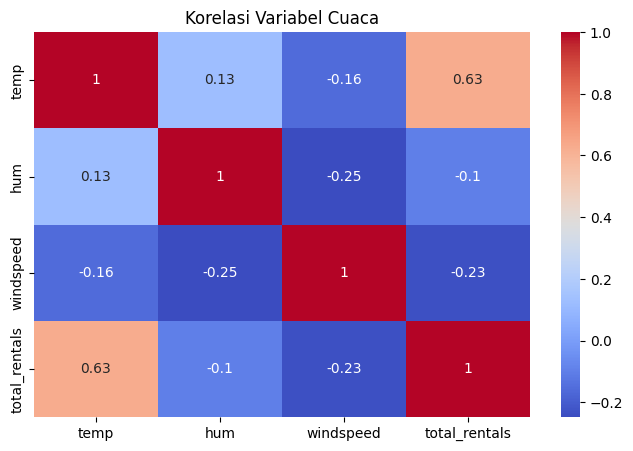

In [40]:
plt.figure(figsize=(8,5))
sns.heatmap(day_df[['temp','hum','windspeed','total_rentals']].corr(),
            annot=True, cmap='coolwarm')

plt.title('Korelasi Variabel Cuaca')
plt.show()

**Insight:**
- Suhu (temp) memiliki korelasi positif cukup kuat terhadap penyewaan (+0.63)
- Kelembaban (hum) memiliki korelasi negatif lemah (-0.10)
- Kecepatan angin (windspeed) memiliki korelasi negatif (-0.23)

Berdasarkan hasil dari scatter plot dan heatmap Suhu merupakan faktor cuaca yang paling berpengaruh terhadap jumlah penyewaan sepeda, di mana peningkatan suhu diikuti dengan peningkatan jumlah penyewaan. Sebaliknya, kondisi cuaca yang kurang baik seperti kelembaban tinggi, angin kencang, serta hujan atau salju ringan cenderung menurunkan jumlah penyewaan. Selain itu, kondisi cuaca cerah (Clear) menjadi kondisi paling optimal dengan jumlah penyewaan tertinggi dibandingkan kondisi cuaca lainnya.

## Pertanyaan 3:

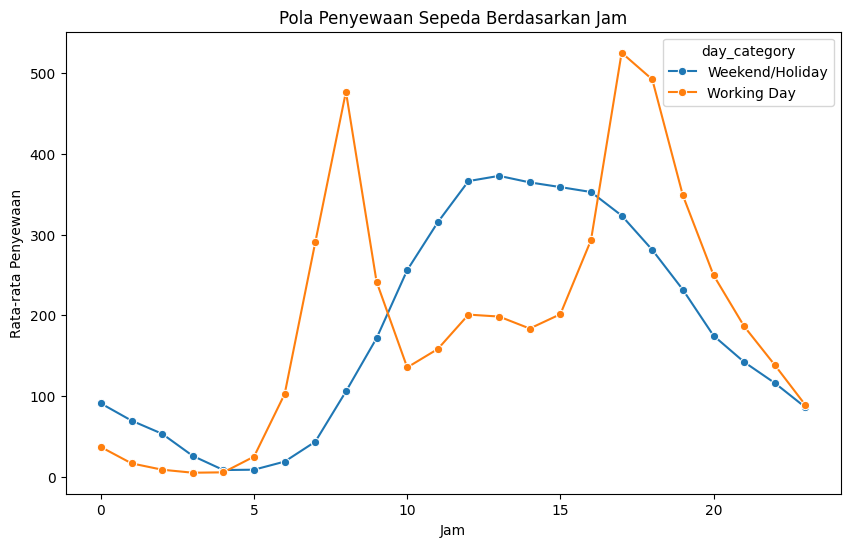

In [41]:
hourly = hour_df.groupby(['hour','day_category'])['total_rentals'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=hourly, x='hour', y='total_rentals', hue='day_category', marker='o')

plt.title('Pola Penyewaan Sepeda Berdasarkan Jam')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

**Insight:**

Berdasarkan visualisasi:
- Hari Kerja (Working Day)
  - Puncak pagi terjadi pada pukul 08.00 (±480)
  - Puncak tertinggi terjadi pada pukul 17.00 (±530)
    → Menunjukkan pola aktivitas komuter (berangkat & pulang kerja)
- Akhir Pekan/Libur (Weekend/Holiday)
  - Puncak terjadi pada pukul 12.00-14.00 (±370)
  - Pola lebih merata, tidak ada lonjakan tajam
    → Menunjukkan aktivitas lebih bersifat rekreasi
- Dini Hari (00.00-05.00)
  - Penyewaan sangat rendah di kedua kategori (<100)
    → Aktivitas pengguna sangat minim

Pola penyewaan sepeda pada hari kerja menunjukkan dua puncak utama pada pagi dan sore hari yang berkaitan dengan aktivitas komuter. Sebaliknya, pada akhir pekan atau hari libur, penyewaan lebih merata dengan puncak pada siang hari, yang mengindikasikan penggunaan sepeda lebih banyak untuk aktivitas rekreasi dibandingkan kebutuhan transportasi rutin.

# **Analisis Lanjutan**

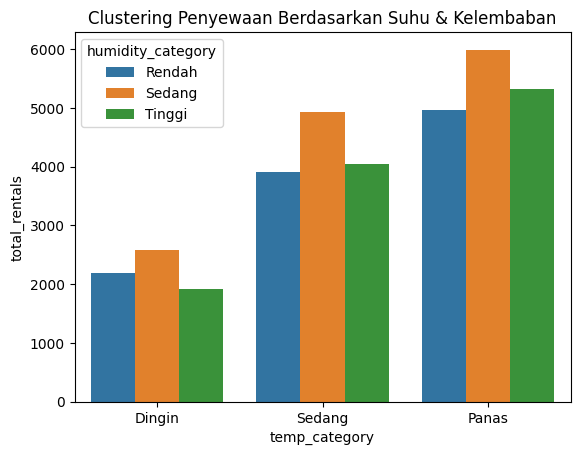

In [43]:
cluster = day_df.groupby(
    ['temp_category','humidity_category'],
    observed=True
)['total_rentals'].mean().reset_index()

sns.barplot(data=cluster,
            x='temp_category',
            y='total_rentals',
            hue='humidity_category',
            errorbar=None)

plt.title('Clustering Penyewaan Berdasarkan Suhu & Kelembaban')
plt.show()

**Insight:**

Berdasarkan visualisasi:
- Suhu Dingin
  - Penyewaan relatif rendah di semua kategori (±1900-2600)
  - Kelembaban tinggi menjadi yang terendah
  → Cuaca dingin, terutama dengan kelembaban tinggi, cenderung mengurangi minat pengguna karena kurang nyaman untuk aktivitas luar ruangan
- Suhu Sedang
  - Terjadi peningkatan cukup signifikan (±3900-4900)
  - Kelembaban sedang menghasilkan penyewaan tertinggi
  → Kondisi cuaca yang sejuk dan stabil menjadi kondisi ideal bagi sebagian besar pengguna
- Suhu Panas
  - Penyewaan tertinggi di semua kategori (±5000-6000)
  - Kelembaban sedang mencapai nilai tertinggi
  → Suhu hangat meningkatkan aktivitas pengguna, namun tetap optimal ketika kelembaban tidak terlalu tinggi
- Pengaruh Kelembaban
  - Kelembaban sedang secara konsisten menghasilkan penyewaan tertinggi
  - Kelembaban tinggi cenderung menurunkan jumlah penyewaan
  → Kelembaban berperan sebagai faktor tambahan yang memengaruhi kenyamanan pengguna

Secara keseluruhan, faktor lingkungan seperti suhu dan kelembaban memiliki pengaruh yang signifikan terhadap perilaku penyewaan sepeda. Penyewaan cenderung meningkat pada kondisi suhu yang lebih hangat dengan tingkat kelembaban yang sedang. Sebaliknya, kondisi cuaca dingin dan kelembaban tinggi menjadi faktor utama yang menghambat aktivitas penyewaan, karena menurunkan kenyamanan pengguna dalam beraktivitas di luar ruangan.

# **Conclusion**

Berdasarkan hasil analisis data penyewaan sepeda pada periode 2011-2012, diperoleh beberapa kesimpulan utama sebagai berikut:

- Tren Penyewaan Sepeda
  - Penyewaan sepeda menunjukkan pola musiman yang jelas, di mana jumlah penyewaan meningkat dari awal tahun hingga mencapai puncaknya pada pertengahan hingga akhir tahun.
  - Puncak tertinggi terjadi pada tahun 2012, khususnya sekitar bulan September dengan jumlah penyewaan mencapai ±220.000.
  - Setelah itu, terjadi penurunan signifikan menjelang akhir tahun (Oktober-Desember).
  - Selain itu, jumlah penyewaan pada tahun 2012 secara konsisten lebih tinggi dibandingkan tahun 2011, dengan selisih rata-rata sekitar 50.000-80.000 per bulan, yang menunjukkan peningkatan penggunaan layanan bike sharing.
- Pengaruh Kondisi Cuaca
  - Suhu memiliki pengaruh paling besar terhadap jumlah penyewaan sepeda, dengan korelasi positif sekitar +0.63, yang menunjukkan bahwa semakin tinggi suhu maka jumlah penyewaan juga meningkat.
  - Pada suhu tinggi, jumlah penyewaan dapat mencapai sekitar ±8000-9000.
  - Sebaliknya, kelembaban (-0.10) dan kecepatan angin (-0.23) memiliki pengaruh negatif terhadap penyewaan.
  - Kondisi cuaca cerah (Clear) menghasilkan jumlah penyewaan tertinggi, sedangkan kondisi seperti hujan atau salju ringan cenderung menurunkan jumlah penyewaan.
- Pola Penyewaan Berdasarkan Waktu
  - Pada hari kerja, terdapat dua puncak penyewaan yaitu pada pagi hari sekitar pukul 08.00 (±480) dan sore hari sekitar pukul 17.00 (±530), yang menunjukkan pola aktivitas komuter.
  - Pada akhir pekan atau hari libur, penyewaan lebih merata dengan puncak pada siang hari sekitar pukul 12.00-14.00 (±370), yang mengindikasikan penggunaan sepeda untuk aktivitas rekreasi.
  - Pada dini hari (00.00-05.00), jumlah penyewaan sangat rendah di kedua kategori (<100), yang menunjukkan minimnya aktivitas pengguna.
- Clustering Suhu dan Kelembaban
  - Penyewaan sepeda meningkat seiring dengan kenaikan suhu, yaitu pada suhu dingin berkisar ±1900-2600, meningkat pada suhu sedang menjadi ±3900-4900, dan mencapai nilai tertinggi pada suhu panas sekitar ±5000-6000.
  - Kelembaban sedang secara konsisten menghasilkan jumlah penyewaan tertinggi di semua kategori suhu.
  - Kelembaban tinggi cenderung menurunkan jumlah penyewaan, terutama pada suhu dingin.
  - Kombinasi kondisi terbaik terjadi pada suhu panas dengan kelembaban sedang (±6000), sedangkan kombinasi terburuk terjadi pada suhu dingin dengan kelembaban tinggi (±1900).

Secara keseluruhan, pola penyewaan sepeda dipengaruhi oleh kombinasi faktor waktu dan kondisi lingkungan. Suhu menjadi faktor utama yang meningkatkan jumlah penyewaan, sementara kelembaban dan kondisi cuaca berperan dalam menentukan tingkat kenyamanan pengguna. Selain itu, pola penggunaan sepeda berbeda antara hari kerja dan akhir pekan, yang mencerminkan perbedaan kebutuhan antara aktivitas transportasi rutin dan rekreasi.